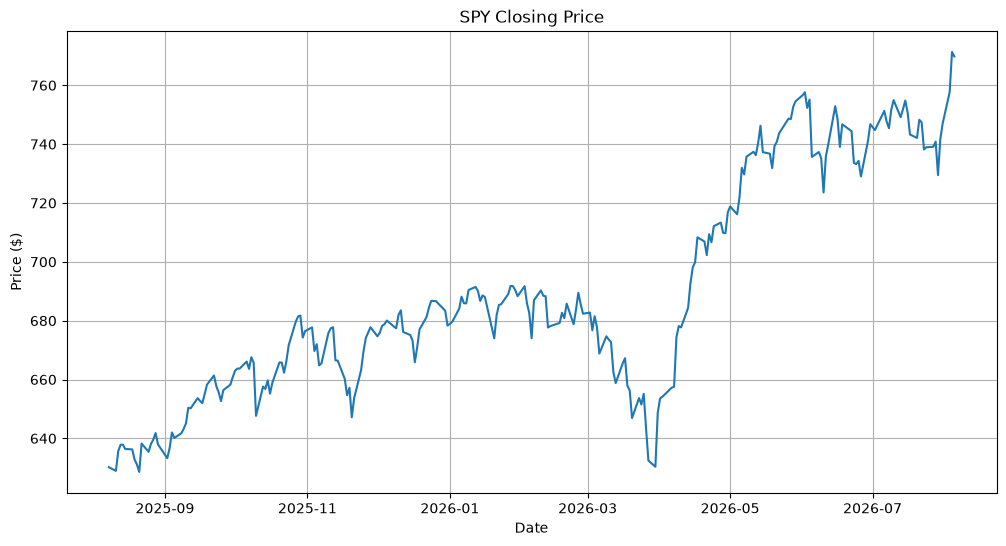

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/historical/SPY_Returns.csv",
    index_col="Date",
    parse_dates=True
)

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"])

plt.title("SPY Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.grid(True)

plt.savefig(
    "../report/SPY_Price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

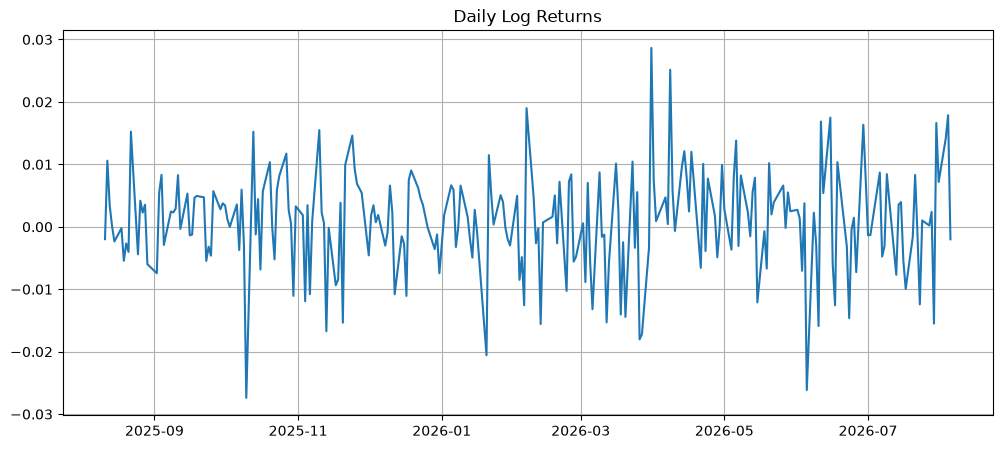

In [2]:
import numpy as np

df["Log Return"] = np.log(
    df["Close"] /
    df["Close"].shift(1)
)

plt.figure(figsize=(12,5))

plt.plot(df.index,
         df["Log Return"])

plt.title("Daily Log Returns")

plt.grid(True)

plt.savefig(
    "../report/Log_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

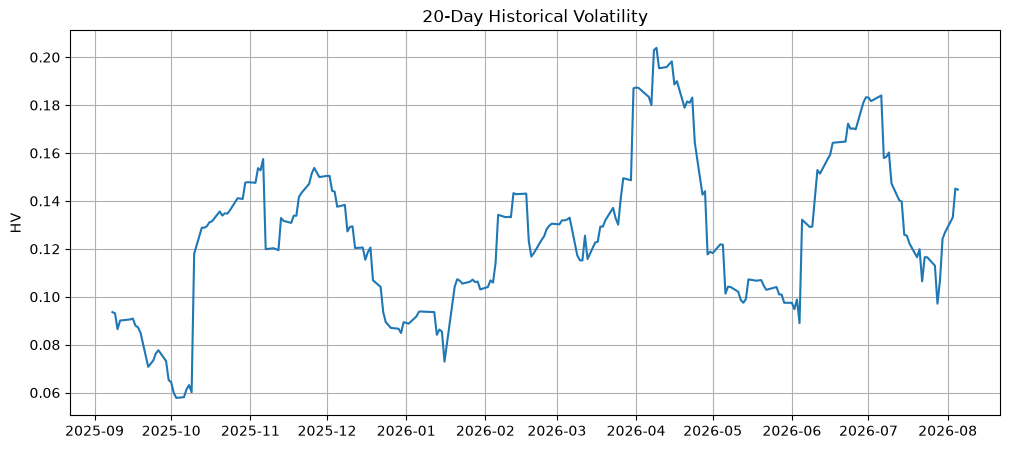

In [3]:
rolling_hv = (
    df["Log Return"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

plt.figure(figsize=(12,5))

plt.plot(
    rolling_hv.index,
    rolling_hv
)

plt.title("20-Day Historical Volatility")

plt.ylabel("HV")

plt.grid(True)

plt.savefig(
    "../report/20Day_HV.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

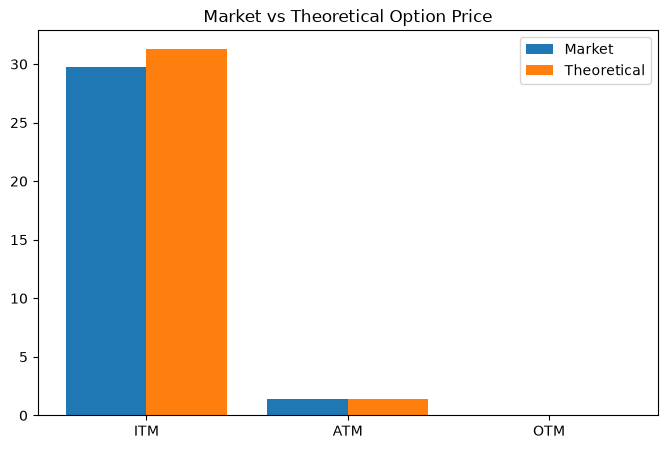

In [4]:
import matplotlib.pyplot as plt

labels = ["ITM","ATM","OTM"]

market = [29.78,1.38,0.01]

theoretical = [
    31.31,
    1.433,
    0.0098
]

x = range(len(labels))

plt.figure(figsize=(8,5))

plt.bar(
    x,
    market,
    width=0.4,
    label="Market"
)

plt.bar(
    [i+0.4 for i in x],
    theoretical,
    width=0.4,
    label="Theoretical"
)

plt.xticks(
    [i+0.2 for i in x],
    labels
)

plt.legend()

plt.title("Market vs Theoretical Option Price")

plt.savefig(
    "../report/Market_Vs_Theoretical.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

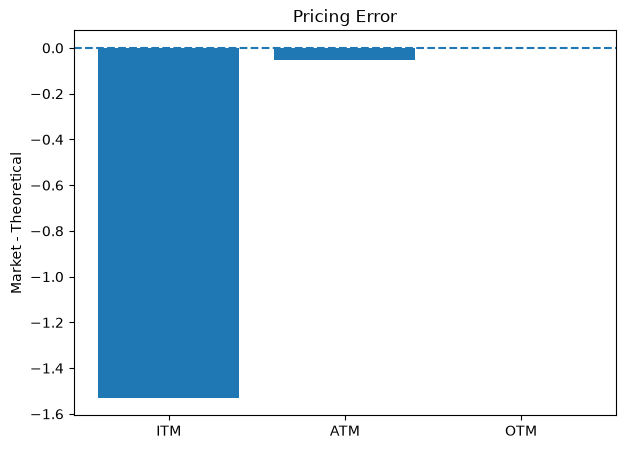

In [5]:
pricing_error = [
    -1.53,
    -0.053,
    0.00019
]

labels = [
    "ITM",
    "ATM",
    "OTM"
]

plt.figure(figsize=(7,5))

plt.bar(
    labels,
    pricing_error
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Pricing Error")

plt.ylabel("Market - Theoretical")

plt.savefig(
    "../report/Pricing_Error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()